# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement
The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.



### Data Dictionary

The data includes various information related to a food order. A detailed data dictionary is provided below.

Data Dictionary

*   order_id: Unique ID of the order

*   customer_id: ID of the customer who ordered the food

*   restaurant_name: Name of the restaurant
*   cuisine_type: Cuisine ordered by the customer
*   cost_of_the_order: Cost of the order
*   day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
*   rating: Rating given by the customer out of 5
*   food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
*   delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information




### Let us start by importing the required libraries

In [1]:
# import necessary libraries for the project
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

### Understanding the structure of the data

In [2]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
#To read the data,
#foodhub_order.csv file is located in the same location as in the python notebook. So directly we can mention the file name without path.
df = pd.read_csv('foodhub_order.csv')

In [4]:
#View the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [5]:
# Understand and view the last 5 rows
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [6]:
# view the sample of 100 rows to see the data in random sample.
df.sample(100)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
702,1477017,175101,TAO,Japanese,15.76,Weekend,Not given,26,19
1548,1477484,143984,Blue Ribbon Fried Chicken,American,6.79,Weekend,3,28,27
356,1476599,47386,Bubby's,American,22.75,Weekend,5,32,16
1021,1477169,46696,Blue Ribbon Sushi Bar & Grill,Japanese,12.08,Weekday,5,29,24
1571,1476547,83095,Bareburger,American,6.84,Weekend,5,22,24
...,...,...,...,...,...,...,...,...,...
576,1477743,104130,Blue Ribbon Sushi,Japanese,6.64,Weekend,Not given,23,15
232,1476566,103884,S'MAC,American,14.46,Weekend,Not given,34,17
670,1477302,52832,Don's Bogam BBQ & Wine Bar,Korean,12.23,Weekend,Not given,32,20
917,1477148,385406,The Meatball Shop,Italian,11.59,Weekday,Not given,21,30


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [7]:
# find the shape of the data to understand the size of the data
df.shape
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### **Observations**:
*The data has 1898 rows and 9 columns.*


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
# check the datatypes of columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### **Observations**:
*There are attributes of different types (int, object, float) in the data.*

*There are **5 numerical columns**: order_id, customer_id, food_preparation_time, delivery_time, cost_of_the_order.*

*There are **4 categorical columns**: restaurant_name, cuisine_type,day_of_the_week, rating.*


Note:

*We see the **rating** column is given as **categorical** type.
It has values as both numeric values and 'Not given' as rating values.*

*rating column dont have any missing values. if we want to analyse on ratings of a particular restaurent, then we need to exclude 'Not given' values from caluclations like minimum rating, average ratings and all other aggregations.*

*We can further investigate on this column with business and can make decisions based on the inputs received whether we can fill all the 'Not given' values as '0' which means 'no rating' to make the rating column more sense.*




In [9]:
#find all the unique values in 'rating' column
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [10]:
#convert the type of rating field to integer column. if we want to work on ratings, then we need to convert the categorical column to int type. so that we can work on rating column to analyse the statistical computations like Average ratings, min, max and so on.
def check_valid_rating(x):
    if x == 'Not given':
        return 0
    else:
        return int(x)

#we will derive a new column which will hold only numeric ratings from 'rating' and will replace all 'Not Given' as 0
df['valid_ratings'] = df['rating'].apply(check_valid_rating)
df['valid_ratings'].unique()


array([0, 5, 3, 4])

In [11]:
#we observe that our new column holds numeric data and type is int.
#we can utilize this column to perform statistical analysis on rating column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   valid_ratings          1898 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 148.4+ KB


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [12]:
# Find if any missing values in the data.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   valid_ratings          1898 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 148.4+ KB


*When we check the info of data, we see the non-null count same as total tow count 1898. So this proves that there are no mising values/nan in the data set.*

In [13]:
# we can even check the same missing values using df.isnull().sum(). This will provide the total count of missing values in each attribute.
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0
valid_ratings,0


#### Observations:
*We observe that isnull count is 0, which means no missing values in all the attributes of the dataset.*

In [14]:
# we can even check if there are any duplications in the data which might effect our analysis.
#Checking for duplicate entries in the dataset
df.duplicated().sum()

np.int64(0)

**Observations**:

*We observe that the count is 0, which means no duplicates in the dataset.*

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [15]:
# Let's check the statistical summary of the data. We transpose the statical summary so that it gives more readability to the summary.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00
valid_ratings,1898.0,2.659642e+00,2.195280,0.00,0.00,4.00,5.000000e+00,5.00


#### **Observations**:

- *The minimum food preparation time is 20 minutes, and the maximum is 35 minutes, with an average of about 27.4 minutes.*
- *The average cost of an order is around $16.50.*
- *The minimum delivery time is 15 minutes, and the maximum is 33 minutes, with an average of about 24.2 minutes.*
- *The least rating is 0(this is considering the 0 ratings (Not given ratings ) which we did in our initial steps of data cleanup) , the maximum rating is 5, average rating is 2.6.*

### **Question 5:** How many orders are not rated? [1 mark]

In [16]:
# To find orders that are not rated, we can consider to find all orders that have rating as 'Not given'.
df[df['rating'] == 'Not given'].shape[0]

#we can even find out with the new column that we added 'valid_ratings'
#df[df['valid_ratings'] == 0].shape[0]

736

#### **Observations**:
*There are 736 orders that are not rated or rating is 'Not given'.*

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [17]:
# verify all the numeric columns
df.select_dtypes(include=['number']).columns

Index(['order_id', 'customer_id', 'cost_of_the_order', 'food_preparation_time',
       'delivery_time', 'valid_ratings'],
      dtype='object')

In [18]:
# verify all the categorical columns
df.select_dtypes(include=['object']).columns

Index(['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating'], dtype='object')

To Perform the  Univariate analysis, we will do it on both numeric and categorical columns.

We need to identify all the numeric columns as well as categorical columns in  the dataset to better visualize them to make most of the sense  from the data set.

**Numeric Columns**:
df.select_dtypes(include=['number']).columns - to get all numeric columns

* 'order_id'
* 'customer_id'
* 'cost_of_the_order'
* 'food_preparation_time'
* 'delivery_time'
* 'valid_ratings'


**Categorical Columns**:
df.select_dtypes(include=['object']).columns - to get all categorical columns

* 'restaurant_name'
* 'cuisine_type'
* 'day_of_the_week'
* 'rating'

In summary for univariate analysis, we will create plots for below attributes to make good sense.

We will use histograms and boxplots for numerical variables

* 'cost_of_the_order'
* 'food_preparation_time'
* 'delivery_time'
* 'valid_ratings'

countplots for categorical variables.
* 'cuisine_type'
* 'day_of_the_week'
* 'rating'


Lets create histplot and box plots for these numeric attributes:
* cost_of_the_order
* food_preparation_time
* delivery_time

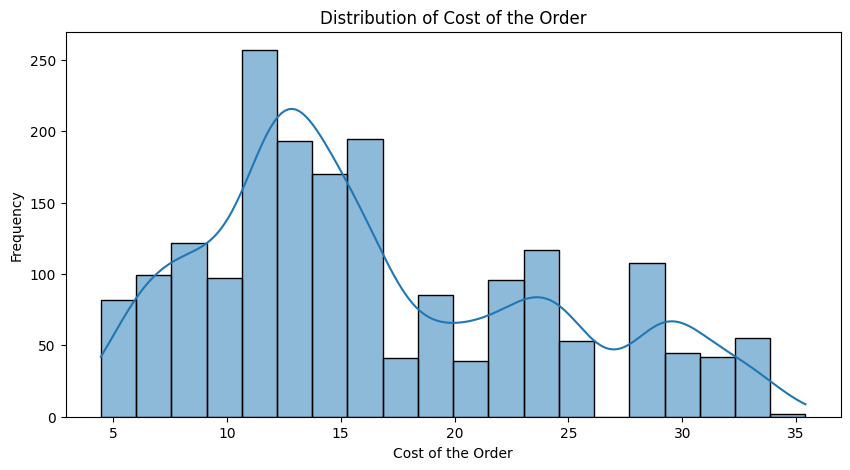

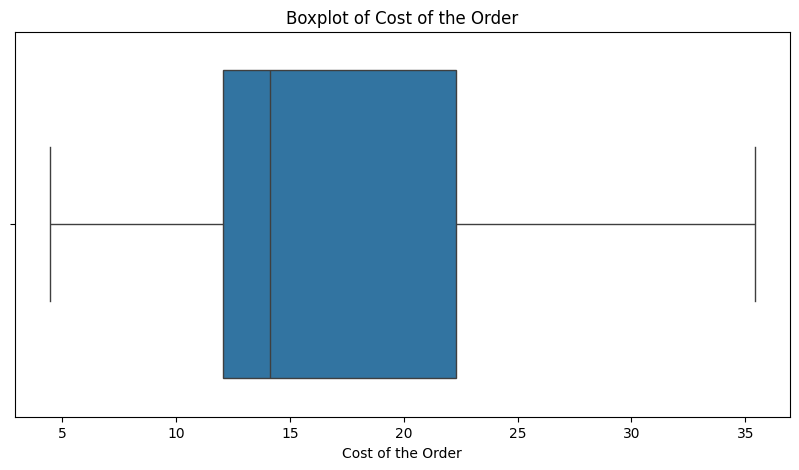

In [19]:
## Explore the distribution of 'cost_of_the_order'
#Lets set all the labels of the plot like xLabel, yLabel, title of the plot, and size of the plot to make the plot look good.

#histogram for cost or order
plt.figure(figsize=(10, 5))
plt.title('Distribution of Cost of the Order')
plt.xlabel('Cost of the Order')
plt.ylabel('Frequency')
sns.histplot(df['cost_of_the_order'], bins=20, kde=True);

#boxplot for cost of order
plt.figure(figsize=(10, 5))
plt.title('Boxplot of Cost of the Order')
plt.xlabel('Cost of the Order')
sns.boxplot(x=df['cost_of_the_order']);

**Observations on the distribution of 'cost_of_the_order':**

* *The histogram shows that the majority of orders have a cost between approximately 11 and 25.*

* *There is a huge number of orders between the 10-15 dollars cost range.*

* *We see that the distribution is right-skewed, meaning there are less orders with very high costs when compared to lower costs.*

* *The boxplot confirms that right-skewness, with the median closer to the lower quartile and a longer whisker on the right side.*



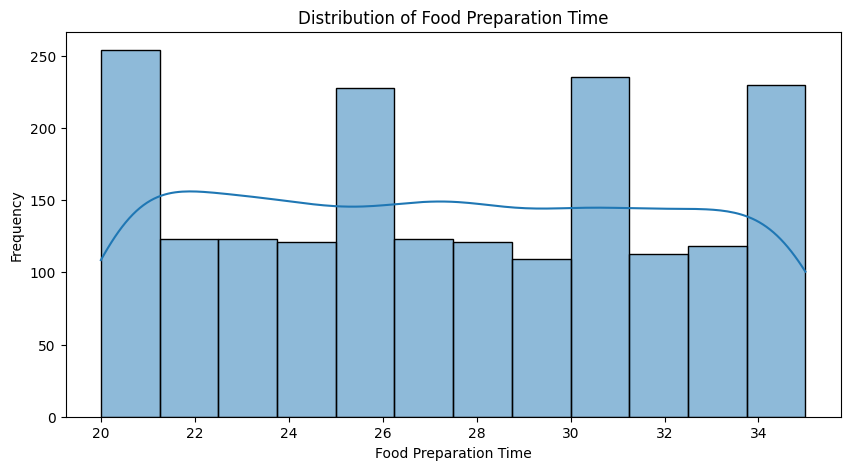

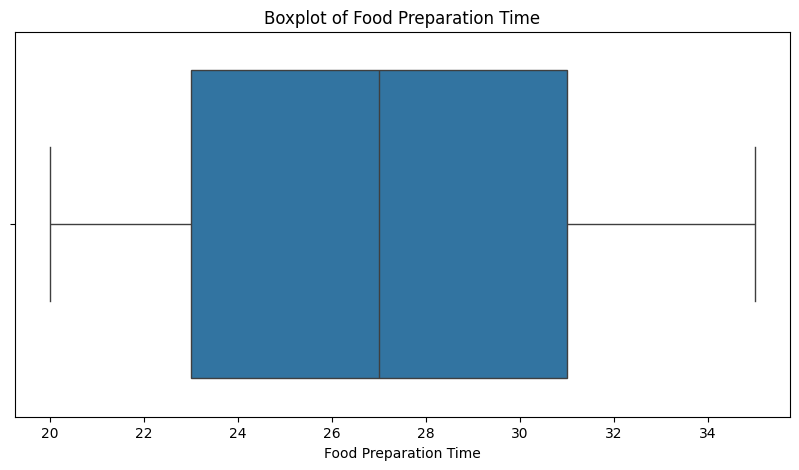

In [20]:
# Explore the distribution of 'food_preparation_time'
plt.figure(figsize=(10, 5))
plt.title('Distribution of Food Preparation Time')
plt.xlabel('Food Preparation Time')
plt.ylabel('Frequency')
sns.histplot(df['food_preparation_time'], kde=True);


plt.figure(figsize=(10, 5))
plt.title('Boxplot of Food Preparation Time')
plt.xlabel('Food Preparation Time')
sns.boxplot(x=df['food_preparation_time']);

**Observations on the distribution of 'food_preparation_time':**

* *The histogram shows that the food preparation time is distributed around between 20 to 35 minutes.*

* *The distribution looks to be normal or its uniform  across between 20 and 35 minutes, with a little increase around the peak at 34.*

* *The boxplot confirms the range of food preparation times and shows that the median is around 27 minutes.*

* *The boxplot also indicates that there are no outliers in the food preparation time.*

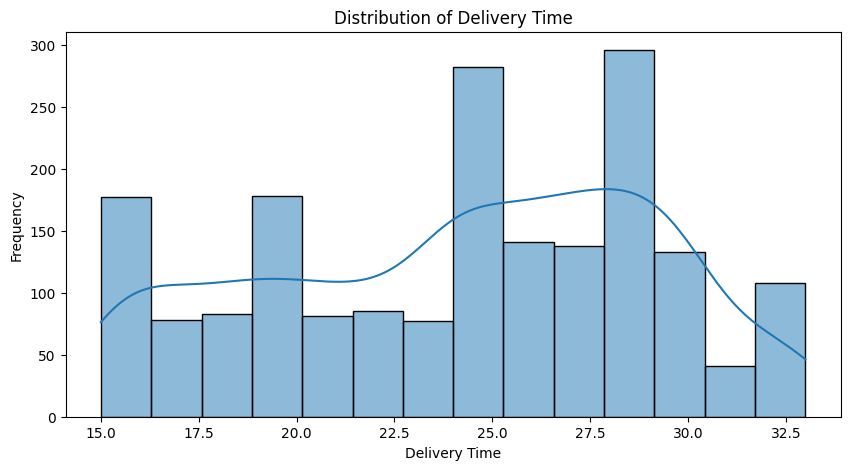

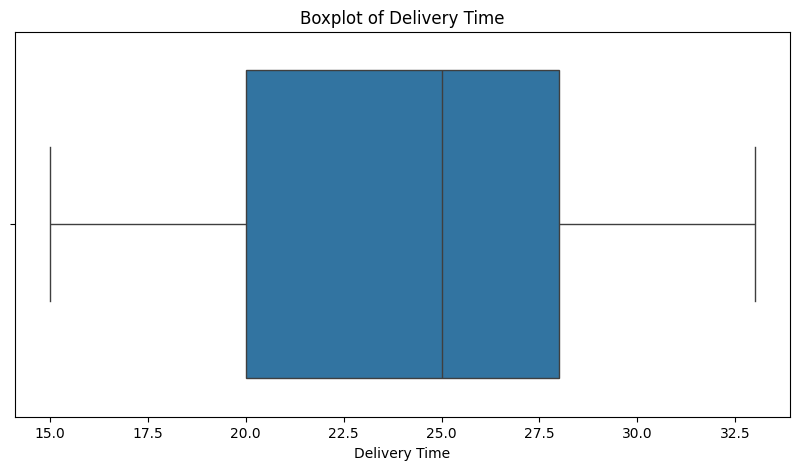

In [21]:
# Explore the distribution of 'delivery_time'
plt.figure(figsize=(10, 5))
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Frequency')
sns.histplot(df['delivery_time'], kde=True);


plt.figure(figsize=(10, 5))
plt.title('Boxplot of Delivery Time')
plt.xlabel('Delivery Time')
sns.boxplot(x=df['delivery_time']);

**Observations on the distribution of 'delivery_time':**

* *The histogram shows that the delivery time is distributed between 15 and 33 minutes.*

* *There is a peak in the frequency of delivery time around 28.5 minutes.*

* *The distribution appears to be slightly right-skewed, meaning there are fewer orders with very long delivery times compared to shorter times.*

* *The boxplot shows that the median is around 25 minutes.*

* *The boxplot also indicates that there are no outliers in the delivery time also.*

Lets explore categorical attributes using countplots for the below:
* *cuisine_type*
* *day_of_the_week*
* *rating*

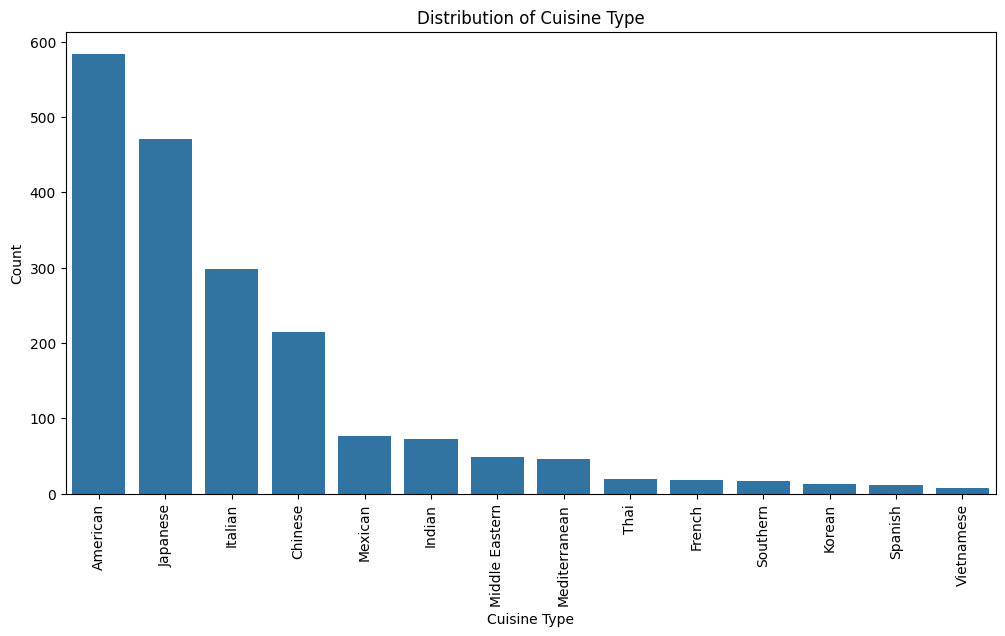

In [22]:
# Explore the distribution of 'cuisine_type'
plt.figure(figsize=(12, 6))

plt.title('Distribution of Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Count')
plt.xticks(rotation=90)

#arrange the cuisine_type value counts in descending and set order to display in the plot.
cuisine_type_counts = df['cuisine_type'].value_counts().index
sns.countplot(x=df['cuisine_type'], order=cuisine_type_counts);

**Observations on the distribution of 'cuisine_type':**

* *The countplot shows the frequency of each cuisine type in the dataset.*

* *American cuisine is the most popular, followed by Japanese and Italian, Chinese.*

* *There is a wide variety of cuisine types available, with some being much more popular than others.*

* *The distribution is right skewed, as we see major frequency counts are visible in cuisines American, Japanese, Chinese. All others are not that popular.*

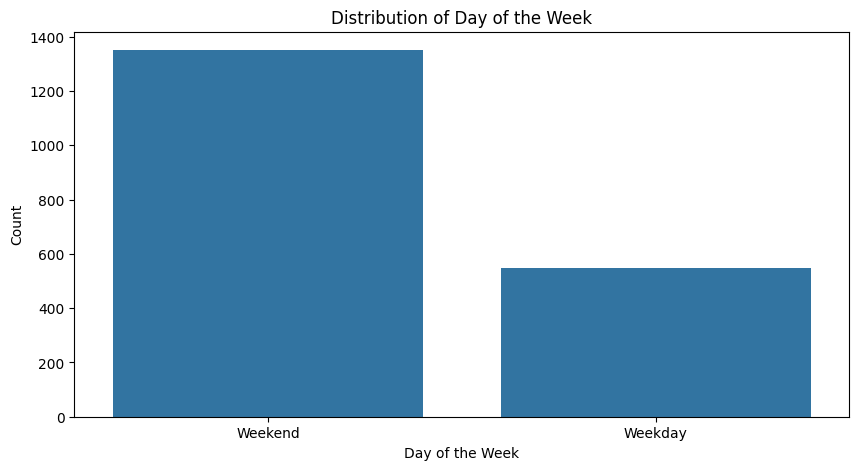

In [23]:
# Explore the distribution of 'day_of_the_week'
plt.figure(figsize=(10, 5))

plt.title('Distribution of Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')

sns.countplot(x=df['day_of_the_week']);

**Observations on the distribution of 'day_of_the_week':**

* *The countplot shows the number of orders placed on weekdays and weekends.*

* *There are significantly more orders placed on weekends compared to weekdays.*

* *This tells us that the food delivery service is more during the weekends.*

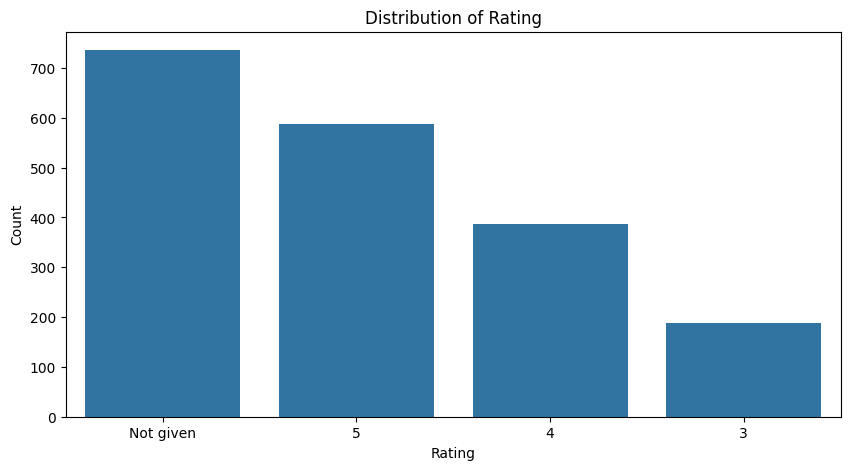

In [24]:
# Explore the distribution of 'rating'
plt.figure(figsize=(10, 5))
plt.title('Distribution of Rating')
plt.xlabel('Rating')
plt.ylabel('Count')

#arrange the ratings counts in descending order and them plot to get more clarity in the plot
rating_counts = df['rating'].value_counts().index
sns.countplot(x=df['rating'], order=rating_counts);

**Observations on the distribution of 'rating':**

* *The countplot shows the frequency of each rating value.*

* *Major orders are not rated.*

* *The most frequent provided rating is 5, followed by 4 and 3.*

* *This indicates that a large portion of orders were not rated by customers.*

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


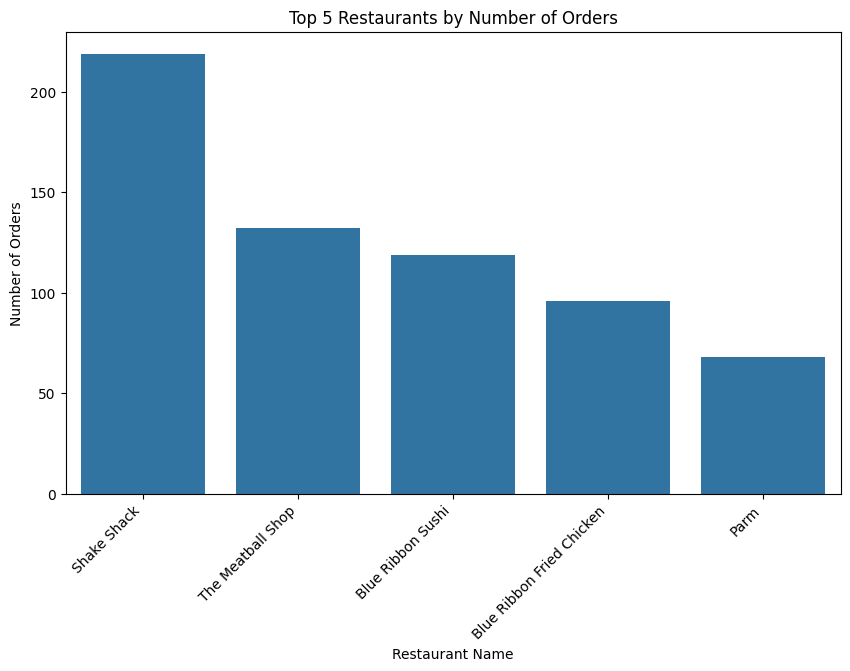

In [25]:
#Extract all the restaurents by using value_counts. it will give counts in descending order. so fetch first five using head()
restaurents = df['restaurant_name'].value_counts()
print(restaurents.head())

# plot these top 5 restaurents in the count plot
plt.figure(figsize=(10, 6))

plt.title('Top 5 Restaurants by Number of Orders')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability

sns.countplot(x=df['restaurant_name'], order=restaurents.head().index);



#### **Observations**:

From the above, we can confirm that top 5 restaurents are:
1. *Shake Shack with 219 orders*
2. *The Meatball Shop with 132 orders*
3. *Blue Ribbon Sushi with 119 orders*
4. *Blue Ribbon Fried Chicken with 96 orders*
5. *Parm with 68 orders*


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [26]:
# Filter for weekend orders from dataframe and get value counts of cuisine_type
cuisine_types_counts = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()
cuisine_types_counts


,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### **Observations**:
*From value counts of cuisine type for weekend data, we can see that the most popular cuisines are American, followed by Japanese, Italian, Chinese.*

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [27]:
# first fetch the orders which have cost more than 20 dollars
orders_with_cost_greater_20 = df[df['cost_of_the_order'] > 20]
orders_with_cost_greater_20

total_orders_with_cost_greater_20 = len(orders_with_cost_greater_20)
total_orders = len(df)

percentage_orders_with_cost_greater_20 = (total_orders_with_cost_greater_20 / total_orders) * 100

print(f"Total orders with cost greater than 20 dollars: {total_orders_with_cost_greater_20}")

print(f"Total orders: {total_orders}")

print(f"Percentage of orders costing more than 20 dollars: {percentage_orders_with_cost_greater_20:.2f}%")

Total orders with cost greater than 20 dollars: 555
Total orders: 1898
Percentage of orders costing more than 20 dollars: 29.24%


#### **Observations**:
*29.24% of the orders in the dataset cost more than 20 dollars.*


### **Question 10**: What is the mean order delivery time? [1 mark]

In [28]:
#we can see statistical summary of delivery_time using describe for that column only.
df['delivery_time'].describe().T

,delivery_time
count,1898.000000
mean,24.161749
std,4.972637
min,15.000000
25%,20.000000
50%,25.000000
75%,28.000000
max,33.000000


#### **Observations**:
From the above, We see that:

* *Mean delivery time for an order is around 24 minutes.*

* *Minimum time taken for delivering an order is 15 minutes.*

* *Major or Long time taken for delivering for an order is 33 minutes.*

* *Most of the orders which is 75% of orders are delivered within 28 minutes.*


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [29]:
# fetch the customer ids and get value_counts to get most frequent customers.
df['customer_id'].value_counts().head()

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


#### **Observations**:
*Frequently ordered top 3 customers are with IDS:  52832, 47440, 83287. So these customers should receive the offer of 20% discount vouchers.*

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


*We can perform multi variate analysis to explore relationships between different variables.*
*For Multi variate analysis, we can use Scatterplots, boxplots, heatmaps.*

**Bivariate analysis between Numerical columns**
* cost_of_the_order
* food_preparation_time
* delivery_time

*We will create a heatmap for all numeric columns except the id columns order_id, customer_id(as these are identity columns and wont have any pattern in them.)*

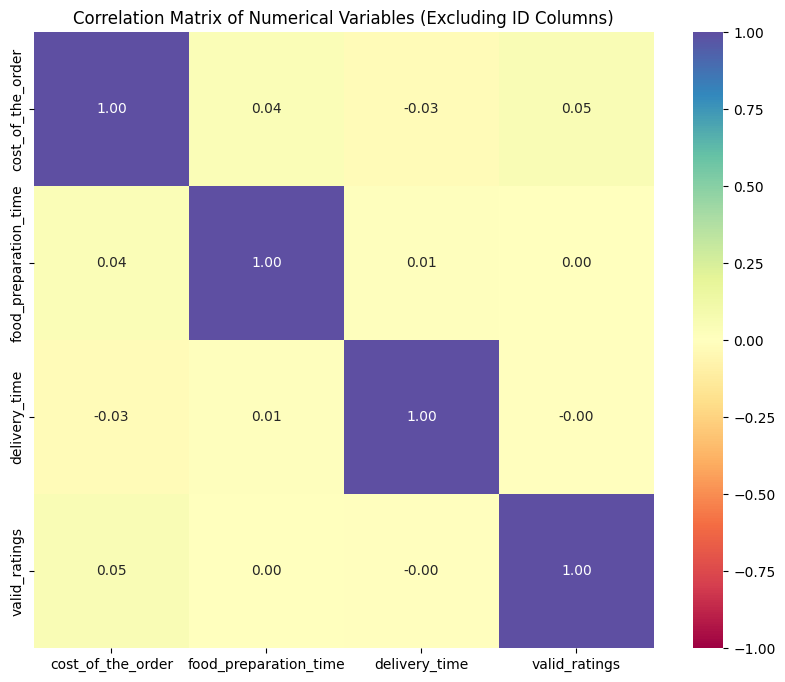

In [30]:
# Select only numerical columns for correlation analysis and exclude 'order_id' and 'customer_id'
numerical_cols = df.select_dtypes(include=np.number).columns.drop(['order_id', 'customer_id'])

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))

plt.title('Correlation Matrix of Numerical Variables (Excluding ID Columns)')
sns.heatmap(correlation_matrix, annot=True, cmap='Spectral',vmin=-1,vmax=1, fmt=".2f");

**Observations:**

* **Cost of the Order and Food Preparation Time**: There is a very weak positive correlation (0.04) between the cost of the order and food preparation time. This suggests that as the cost of the order slightly increases, the food preparation time might also slightly increase, but the relationship is not strong.

* **Cost of the Order and Delivery Time**: There is a very weak negative correlation (-0.03) between the cost of the order and delivery time. This indicates that as the cost of the order slightly increases, the delivery time might slightly decrease, but again, the relationship is not strong.

* **Food Preparation Time and Delivery Time**: There is a very weak positive correlation (0.01) between food preparation time and delivery time. This suggests almost no linear relationship between these two variables. Overall, the heatmap shows very weak correlations between cost_of_the_order, food_preparation_time, and delivery_time. This means that changes in one of these variables do not strongly predict changes in the others.

**Bivariate analysis: Numerical and Categorical columns**

In [31]:
#cuisine_type vs cost_of_the_Order analysis with hue as 'day of the week':
#lets  group the data for these attributes and get average cost of the orders for each cuisine and then plot it to have more meaningful insigts on it.

# Calculate the mean cost of the order by cuisine type and day of the week
mean_cost_by_cuisine_type_dayofweek = df.groupby(['cuisine_type', 'day_of_the_week'])['cost_of_the_order'].mean().reset_index()
mean_cost_by_cuisine_type_dayofweek



,cuisine_type,day_of_the_week,cost_of_the_order
0,American,Weekday,15.308343
1,American,Weekend,16.731735
2,Chinese,Weekday,17.147692
3,Chinese,Weekend,16.036442
4,French,Weekday,20.866000
5,French,Weekend,19.381538
6,Indian,Weekday,17.162500
7,Indian,Weekend,16.800816
8,Italian,Weekday,16.890110
9,Italian,Weekend,16.211449


In [32]:
descending_order_cost = df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values(ascending=False).index
descending_order_cost

Index(['French', 'Southern', 'Thai', 'Spanish', 'Middle Eastern', 'Mexican',
       'Indian', 'Italian', 'American', 'Chinese', 'Japanese', 'Mediterranean',
       'Korean', 'Vietnamese'],
      dtype='object', name='cuisine_type')

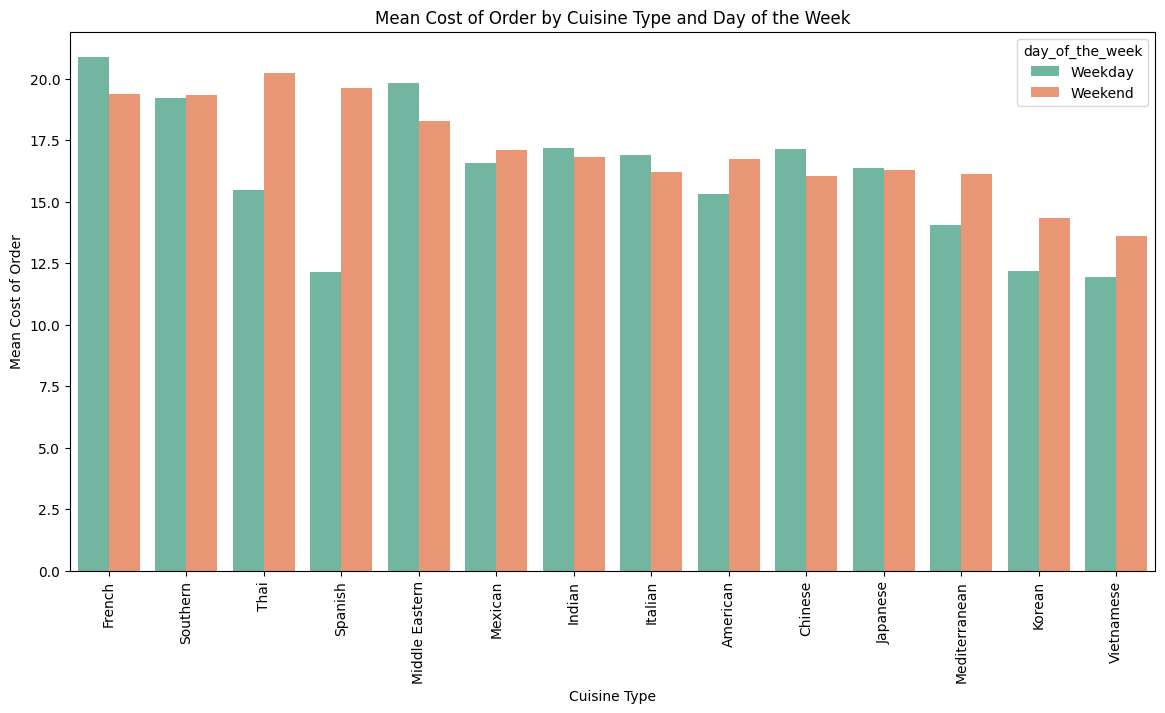

In [33]:

# Visualize the mean cost of the order by cuisine type with day of the week as hue
plt.figure(figsize=(14, 7))

plt.title('Mean Cost of Order by Cuisine Type and Day of the Week')
plt.xlabel('Cuisine Type')
plt.ylabel('Mean Cost of Order')
plt.xticks(rotation=90)

sns.barplot(data=mean_cost_by_cuisine_type_dayofweek,
            x='cuisine_type',
            y='cost_of_the_order',
            hue='day_of_the_week',
            order=descending_order_cost, palette='Set2');


**Observations on Mean Cost of Order by Cuisine Type and Day of the Week as hue:**

*   *French cuisine has the highest average order cost, followed by Southern and Thai cuisines. These are the most expensinve cuisines.*
*   *Vietnamese and Korean cuisines appear to have the lowest average order costs. These are least expensive ones.*

* *For many cuisines like Southern, Thai, Spanish, Mediterranean, Korean, Vietnamese, the avg cost of orders is higher on weekends compared to weekdays. This indicates that the customers are ready to order more expensive items on weekends.*



# Visualize the mean cost of the order by cuisine type with rating as hue

In [34]:
#cuisine_type vs cost_of_the_Order analysis with rating:
#lets  group the data for these two attributes and get average cost of the orders for each cuisine and then plot it to have more meaningful insigts on it.

# Calculate the mean cost of the order by cuisine type and day of the week
mean_cost_by_cuisine_type_rating = df.groupby(['cuisine_type', 'rating'])['cost_of_the_order'].mean().reset_index()
mean_cost_by_cuisine_type_rating

,cuisine_type,rating,cost_of_the_order
0,American,3,16.475313
1,American,4,15.825000
2,American,5,17.675345
3,American,Not given,15.479630
4,Chinese,3,15.438750
5,Chinese,4,16.822750
6,Chinese,5,16.077826
7,Chinese,Not given,16.497683
8,French,3,15.935000
9,French,4,19.113333


In [35]:

#sort the group by first cuisine and then mean cost values
sorted_mean_cost_by_cuisine_type_rating = mean_cost_by_cuisine_type_rating.sort_values(by=['cuisine_type', 'cost_of_the_order'], ascending=[True, False])
sorted_mean_cost_by_cuisine_type_rating

,cuisine_type,rating,cost_of_the_order
2,American,5,17.675345
0,American,3,16.475313
1,American,4,15.825000
3,American,Not given,15.479630
5,Chinese,4,16.822750
7,Chinese,Not given,16.497683
6,Chinese,5,16.077826
4,Chinese,3,15.438750
10,French,5,22.332000
11,French,Not given,19.427500


**Lets visualize the above using bar plots:**


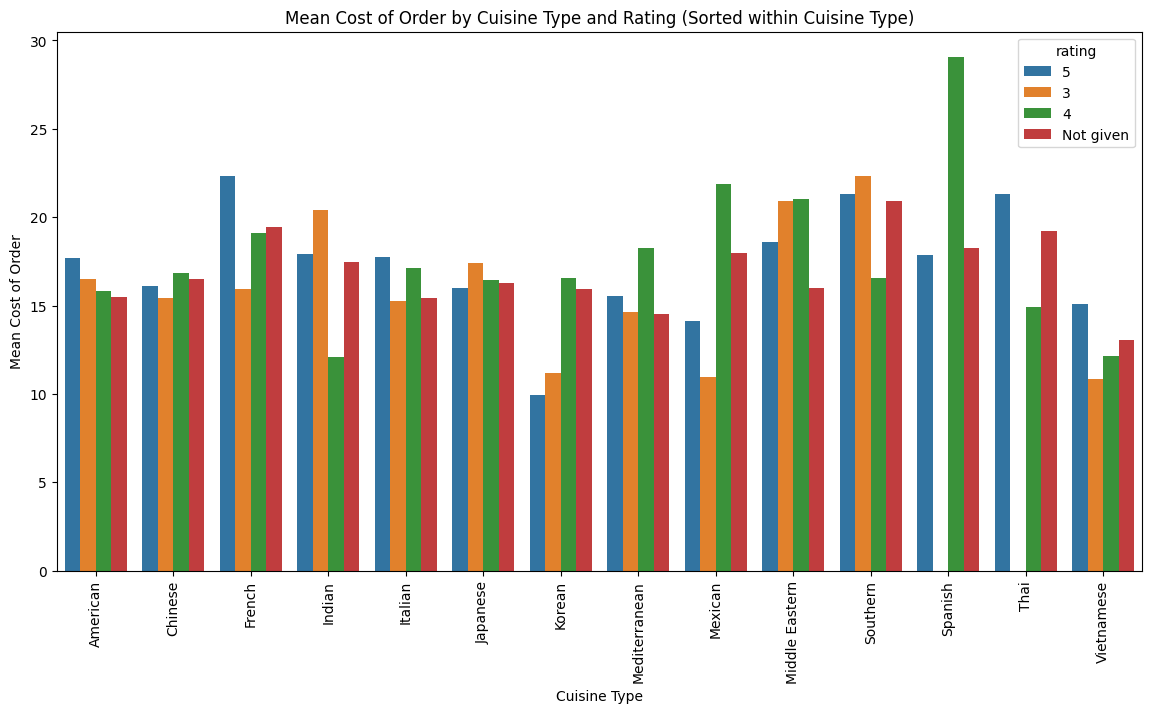

In [36]:
# Visualize the mean cost of the order by cuisine type and rating
plt.figure(figsize=(14, 7))

plt.title('Mean Cost of Order by Cuisine Type and Rating (Sorted within Cuisine Type)')
plt.xlabel('Cuisine Type')
plt.ylabel('Mean Cost of Order')
plt.xticks(rotation=90)

sns.barplot(data=sorted_mean_cost_by_cuisine_type_rating,
            x='cuisine_type',
            y='cost_of_the_order',
            hue='rating');

**Observations on mean cost of the order by cuisine type with rating as hue**:

* *In American cuisine, the highest mean cost have a 5-star rating.*

* *In some cuisines like Mediteranean,  Mexican, Spanish, the highest mean cost is associated with a 4-star rating, not a 5-star rating.*

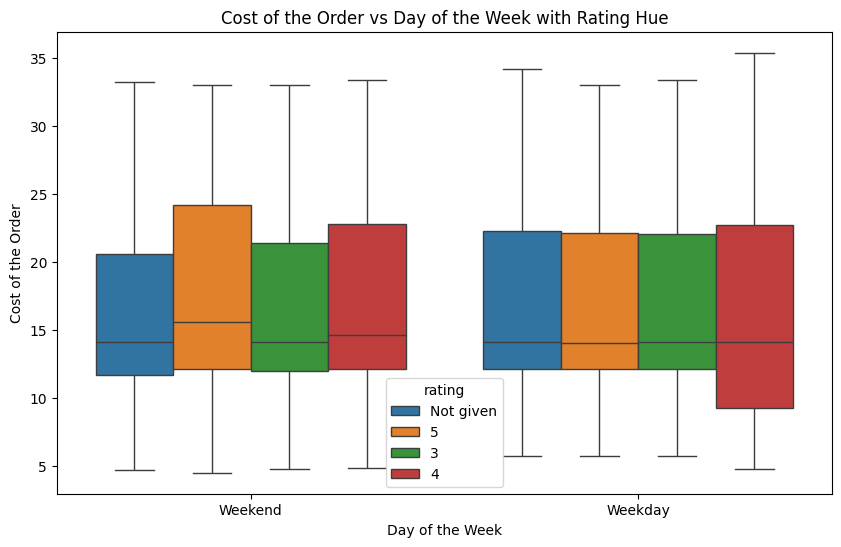

In [37]:
# Box plot of cost of the order vs day of the week with rating as hue
plt.figure(figsize=(10, 6))

plt.title('Cost of the Order vs Day of the Week with Rating Hue')
plt.xlabel('Day of the Week')
plt.ylabel('Cost of the Order')

sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order', hue='rating');

**Observations on Cost of the Order vs Day of the Week with Rating Hue:**

* *On both weekdays and weekends, orders with a rating of 5 tend to have a higher median cost compared to orders with other ratings.*

* *There are outliers (individual points) indicating orders with unusually high or low costs for specific rating categories and days of the week.*

* *The "Not given" rating category has a wide distribution of order costs on both weekdays and weekends, similar to the rated orders.*

* *Overall, this plot suggests that customers who provide a 5-star rating tend to place orders with higher costs, regardless of whether it's a weekday or weekend.*

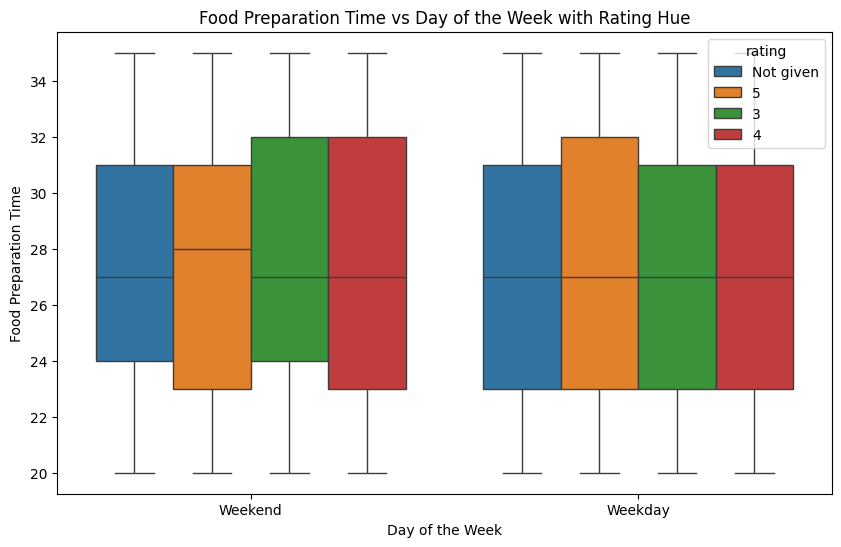

In [38]:
# Box plot of food preparation time vs day of the week with rating as hue
plt.figure(figsize=(10, 6))

plt.title('Food Preparation Time vs Day of the Week with Rating Hue')
plt.xlabel('Day of the Week')
plt.ylabel('Food Preparation Time')
sns.boxplot(data=df, x='day_of_the_week', y='food_preparation_time', hue='rating');

**Observations on Food Preparation Time vs Day of the Week with Rating Hue:**

* *The box plot shows the distribution of food preparation times for weekdays and weekends, categorized by rating.*

* *The food preparation time is alomst same across different ratings on both weekdays and weekends.*

* *we can confirm that rating given for a restaurent doesnot have any effect on food preparation time.*

* *Overall, this plot suggests that the rating given by a customer does not have a strong influence on the food preparation time, regardless of the day of the week.*

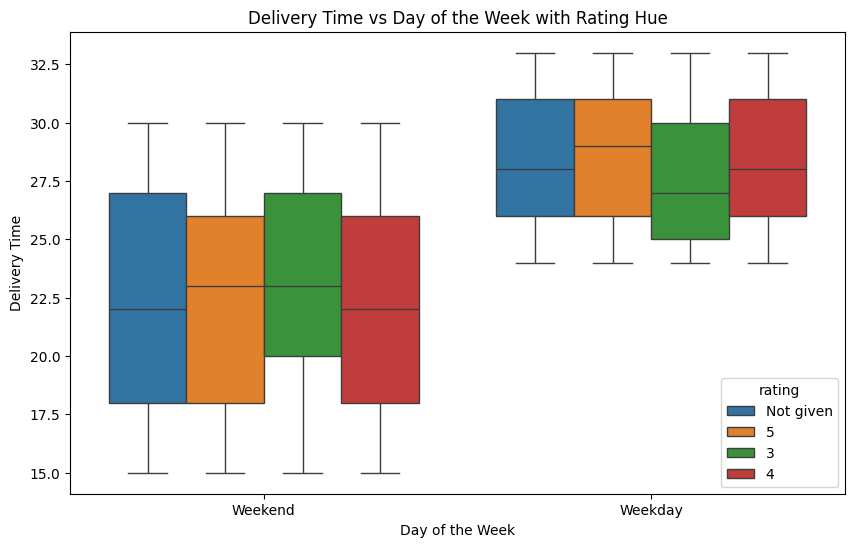

In [39]:
# Box plot of delivery time vs day of the week with rating as hue
plt.figure(figsize=(10, 6))

plt.title('Delivery Time vs Day of the Week with Rating Hue')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time')

sns.boxplot(data=df, x='day_of_the_week', y='delivery_time', hue='rating');

**Observations on Delivery Time vs Day of the Week with Rating Hue:**

* *We see from the above plot that, delivery times appear to be longer on weekdays compared to weekends across all rating categories.*

* *Within both weekdays and weekends, there is no particular pattern that ratings are not much impacting the delivery time.*

* *Overall, while delivery times are longer on weekdays, the customer's rating does not seem to be a strong predictor of the delivery time for an individual order.*

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [40]:
# we need to find restaurents having rating counts > 50, avg rating > 4
#to do this we need to convert the rating column from object to int.
#instead of converting the original column rating, I have created a new column in dataframe called valid_ratings. we will use that column for this question.

# Group the DataFrame by 'restaurant_name' and calculate the count and mean of ratings
restaurant_ratings = df.groupby('restaurant_name').agg(
    rating_count=('valid_ratings', 'count'),
    average_rating=('valid_ratings', 'mean')
)

display(restaurant_ratings)

,rating_count,average_rating
restaurant_name,,
'wichcraft,1,5.000000
12 Chairs,4,2.250000
5 Napkin Burger,5,1.600000
67 Burger,1,5.000000
Alidoro,1,0.000000
...,...,...
Zero Otto Nove,2,2.000000
brgr,2,1.500000
da Umberto,3,1.666667


In [41]:
# rating counts > 50 and avg rating > 4
restaurant_ratings_offer_eligible = restaurant_ratings[(restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['average_rating'] > 4)]
print(restaurant_ratings_offer_eligible.size)


display(restaurant_ratings_offer_eligible)



0


,rating_count,average_rating
restaurant_name,,


#### Observations:
* *When we group all restaurents by name,and valid ratings and see there are 178 rows. But when we filter that criteria ratings_count > 50 and average rating  > 4, no retaurents are qualified.*

* *So we can conclude that there are no restaurents having this criteria to get the prmotional offer.*

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [42]:
#first we will create a function to calculate cost.
def calculate_revenue(cost_of_order):
    if cost_of_order > 20:
        return 0.25 * cost_of_order
    elif cost_of_order > 5:
        return 0.15 * cost_of_order
    else:
        return 0

#for each restaurent, calculate revenue based on the given criteria on cost of order and will store it in new column called revenue.
df['revenue'] = df['cost_of_the_order'].apply(calculate_revenue)
df.head(100)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,valid_ratings,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,0,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,0,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,5,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,3,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,4,1.7385
...,...,...,...,...,...,...,...,...,...,...,...
95,1477027,164016,Blue Ribbon Fried Chicken,American,16.39,Weekend,Not given,27,22,0,2.4585
96,1476921,121476,Blue Ribbon Fried Chicken,American,12.18,Weekday,3,29,27,3,1.8270
97,1476689,305522,Shake Shack,American,24.20,Weekday,4,29,29,4,6.0500
98,1477767,68976,Sarabeth's East,American,17.03,Weekend,3,26,30,3,2.5545


In [43]:

#calculate net revenue by summing all restaurents reveues
net_revenue = df['revenue'].sum()

print(f"The net revenue generated by the FoodHub across all orders is: ${net_revenue:.2f}")


The net revenue generated by the FoodHub across all orders is: $6166.30


#### Observations:
*The net revenue generated by the FoodHub across all orders is: $6166.30*

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [44]:
# Calculate the total delivery time by adding both food preperation time and delivery time and kep it in one new column called total_delivery_time
df['total_delivery_time'] = df['food_preparation_time'] + df['delivery_time']

# Filter for orders that have total time more than 60 minutes from total_delivery_time
long_delivery_times = df[df['total_delivery_time'] > 60]

# Calculate the percentage of orders with long delivery times
percentage_long_delivery = (len(long_delivery_times) / len(df)) * 100

# Display the result
print(f"Percentage of orders that take more than 60 minutes to be delivered: {percentage_long_delivery:.2f}%")

Percentage of orders that take more than 60 minutes to be delivered: 10.54%


#### Observations:
*Percentage of orders that take more than 60 minutes to be delivered: 10.54%*

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [45]:
# group the data by day_of_week and get delivery time and calcualte mean
mean_delivery_time_by_day = df.groupby('day_of_the_week')['delivery_time'].mean()

mean_delivery_time_by_day

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
* *The mean delivery time on weekdays is approximately 28.34 minutes.*

* *The mean delivery time on weekends is approximately 22.47 minutes.*

* *This indicates that the average delivery time is significantly longer on weekdays compared to weekends.*

* *This difference could be due to various factors such as increased traffic during weekday business hours, different staffing levels at restaurants or for delivery personnel, or a higher volume of orders during weekends that might lead to more efficient batching of deliveries.*

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  **Popular Cuisines**: American cuisine is the most popular, followed by Japanese, Italian, and Chinese. Other cuisine types have significantly fewer orders.

* **Order Cost** : The majority of orders fall within a moderate price range ( 10− 25), with a significant number in the  10− 15 range. There's a right-skewness in the distribution indicating that only fewer high-cost orders.

* **Weekend Dominance**: The service is significantly more popular on weekends, with a higher volume of orders compared to weekdays.

* **Food Preparation and Delivery Times**: Delivery times are more longer on weekdays compared to weekends.

* **Restaurant Performance**: No restaurants currently meet the criteria of having both more than 50 ratings and an average rating greater than 4. This indicates that there is a need to encourage more ratings.

* **Revenue Generation**: The revenue model, with higher percentages for orders over  20 and 5, generates a total net revenue of approximately $6166.30 from the analyzed orders.

* **Cuisine, Cost, and Day of the Week**: Mean order costs for most cuisines are slightly higher on weekends, indicating customers might spend more on food delivery during this time.

* **Popular restaurents** are Shake Shack, The Meatball Shop, Blue Ribbon Sushi ,
Blue Ribbon Fried Chicken, Parm

### Recommendations:

*  **Encourage Ratings**: Implement strategies to encourage customers to rate their orders to gather more feedback and identify top-performing restaurants based on ratings. This could involve in-app prompts, post-delivery notifications, or small incentives.

* **Investigate Weekday Delivery Times**: Analyze the factors contributing to longer delivery times on weekdays. This could involve reviewing traffic patterns, optimizing delivery routes, assessing staffing levels, or communicating realistic delivery time estimates to customers.


* **Targeted Cuisines Marketing**: Leverage the popularity of American, Japanese, Italian, and Chinese cuisines, especially on weekends, for targeted marketing campaigns.

* **Analyze Long Delivery Times**: Investigate the specific orders with delivery times exceeding 60 minutes to identify common factors (e.g., restaurant, cuisine, location, time of day) and address potential bottlenecks in the food preparation or delivery process.


* **Weekend Spending Promotion**: Capitalize on the trend of higher weekend spending by offering special weekend promotions or highlighting premium menu items.